# GroundedSAMClean Description

This notebook shows the workflow described  both in the flow segmentation paper and in the groundedSAM paper. This is to better assist in understanding the flow in the 
helper function which follows the same logic.

## GroundingDINO + SAM Setup

Imports dependencies for text-guided object detection (GroundingDINO) and segmentation (SAM), along with utilities for image processing, model loading, and visualization.

In [1]:
import os
import cv2
import torch
import numpy as np
import sys

from groundingdino.util import box_ops
from groundingdino.models import build_model
import groundingdino.datasets.transforms as T
from groundingdino.util.slconfig import SLConfig
from groundingdino.util.utils import clean_state_dict
from groundingdino.util.inference import predict as dino_predict
from groundingdino.util.inference import annotate, load_image
from huggingface_hub import hf_hub_download

import matplotlib.pyplot as plt

from segment_anything import sam_model_registry, SamPredictor

from PIL import Image, ImageOps


/home/leo/miniforge3/envs/FlowSegClean/lib/python3.12/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


## Image Loading

The input frame is loaded from disk and converted to RGB format. It is then displayed to verify correct loading before further processing.

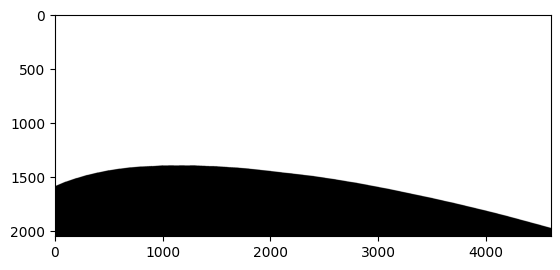

In [2]:
Name1="Frame_00001.tif" #Change name for PIV image used to generate mask
InputPath=os.path.join(os.getcwd(),"input")
GenPath=os.path.join(os.getcwd(),"input",Name1)
MainImage=Image.open(GenPath).convert('RGB')

plt.imshow(np.array(MainImage))

## GroundingDINO Model Initialization

The GroundingDINO model is loaded using a pre-trained configuration and checkpoint from Hugging Face. The model architecture is built from the configuration file, weights are downloaded and loaded, and the network is moved to GPU for inference. Finally, the model is set to evaluation mode for prediction.

In [3]:
repo_id="ShilongLiu/GroundingDINO"
filename="groundingdino_swinb_cogcoor.pth"
config_filename="GroundingDINO_SwinB.cfg.py"
device='cuda'

cache_config_file = hf_hub_download(repo_id=repo_id, filename=config_filename)

args = SLConfig.fromfile(cache_config_file)
Dmodel = build_model(args)
args.device = device

cache_file = hf_hub_download(repo_id=repo_id, filename=filename)
checkpoint = torch.load(cache_file, map_location=device)
log = Dmodel.load_state_dict(clean_state_dict(checkpoint['model']), strict=False)

print("Check the latest .pth from: https://github.com/IDEA-Research/GroundingDINO/releases")

Dmodel.eval()

/home/leo/miniforge3/envs/FlowSegClean/lib/python3.12/site-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4382.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


final text_encoder_type: bert-base-uncased
Check the latest .pth from: https://github.com/IDEA-Research/GroundingDINO/releases


GroundingDINO(
  (transformer): Transformer(
    (encoder): TransformerEncoder(
      (layers): ModuleList(
        (0-5): 6 x DeformableTransformerEncoderLayer(
          (self_attn): MultiScaleDeformableAttention(
            (sampling_offsets): Linear(in_features=256, out_features=256, bias=True)
            (attention_weights): Linear(in_features=256, out_features=128, bias=True)
            (value_proj): Linear(in_features=256, out_features=256, bias=True)
            (output_proj): Linear(in_features=256, out_features=256, bias=True)
          )
          (dropout1): Dropout(p=0.0, inplace=False)
          (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True, bias=True)
          (linear1): Linear(in_features=256, out_features=2048, bias=True)
          (dropout2): Dropout(p=0.0, inplace=False)
          (linear2): Linear(in_features=2048, out_features=256, bias=True)
          (dropout3): Dropout(p=0.0, inplace=False)
          (norm2): LayerNorm((256,), eps=1e-05, elem

## GroundingDINO Inference and Detection Output

The input image is preprocessed and passed through the GroundingDINO model using a text prompt to detect the target object. Bounding boxes, confidence scores, and predicted phrases are returned and converted into pixel coordinates.

A representative detection point is extracted for inspection, and GPU memory is cleared after inference. The detected results are then visualized by overlaying bounding boxes and labels on the original image.

/home/leo/miniforge3/envs/FlowSegClean/lib/python3.12/site-packages/transformers/modeling_utils.py:1052: FutureWarning: The `device` argument is deprecated and will be removed in v5 of Transformers.
  warnings.warn(
/home/leo/miniforge3/envs/FlowSegClean/lib/python3.12/site-packages/torch/_dynamo/eval_frame.py:1298: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/home/leo/miniforge3/envs/FlowSegClean/lib/python3.12/site-packages/torch/utils/checkpoint.py:238: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  check_backward_validity(args)


Height: 2052
Width: 4603
X: 2300
Y: 1716


/home/leo/miniforge3/envs/FlowSegClean/lib/python3.12/site-packages/groundingdino/models/GroundingDINO/transformer.py:862: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):


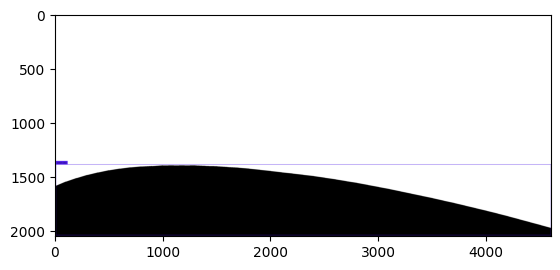

In [4]:
# Image transformation
image_source, image = load_image(GenPath)

height, width, depth = np.array(MainImage).shape

boxes, logits, phrases = dino_predict(model=Dmodel,
                                      image=image,
                                      caption="Airfoil",
                                      box_threshold=0.3,
                                      text_threshold=0.3,
                                      device='cuda')
print(f"Height: {height}")
print(f"Width: {width}")

NumpyBox = boxes.squeeze().cpu().numpy()

XCord = int(width*NumpyBox[0])
YCord = int(height*NumpyBox[1])

print(f"X: {XCord}") 
print(f"Y: {YCord}")      
torch.cuda.empty_cache()

annotated_frame = annotate(image_source=image_source, boxes=boxes, logits=logits, phrases=phrases)
plt.imshow(annotated_frame)

## Image Padding for Processing

A white border is added around the input image to provide additional spatial context and prevent boundary effects during detection and segmentation. The padded image is then displayed for verification.

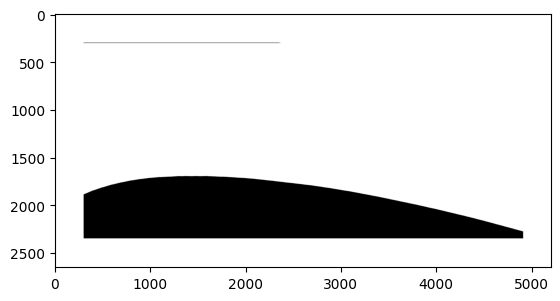

In [5]:
InputImage = ImageOps.expand(MainImage,border=300,fill='white')
plt.imshow(InputImage)

## SAM Segmentation with GroundingDINO Prompt

A pre-trained Segment Anything Model (SAM) is loaded and initialized on GPU. The image is passed to the SAM predictor, and a point derived from the GroundingDINO detection is used as the prompt to generate a segmentation mask.

The resulting mask is converted to a binary format, cropped to remove the padded border, and visualized as a grayscale image for verification.

(2652, 5203)
(2652, 5203)
(2052, 4603)


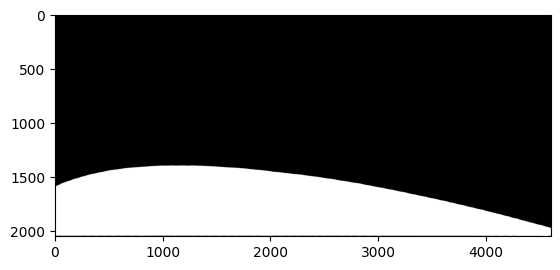

In [6]:

sam_checkpoint = "https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth"
model_type = "vit_h"
device = "cuda"

checkpoint = sam_checkpoint
sam_model = sam_model_registry[model_type]()
state_dict = torch.hub.load_state_dict_from_url(checkpoint)
sam_model.load_state_dict(state_dict, strict=True)

sam_model.to(device=device)

predictor=SamPredictor(sam_model)

predictor.set_image(np.array(InputImage))

masks, _, _ = predictor.predict(
    point_coords=np.array([[XCord+300, YCord+300]]), 
    point_labels=np.array([1]),
    multimask_output=False
)

torch.cuda.empty_cache()

print(masks[0].shape)

mask_uint8 = masks[0].astype(np.uint8) * 255
print(mask_uint8.shape)

CroppedMask=mask_uint8[300:height+300, 300:width+300]
print(CroppedMask.shape)

plt.imshow(CroppedMask, cmap='gray')


## Final Mask Overlay Visualization

The binary segmentation mask is converted into a 3-channel image and colorized to highlight the detected region. It is then blended with the original image using alpha compositing to produce a final visualization that overlays the segmentation result onto the source frame.

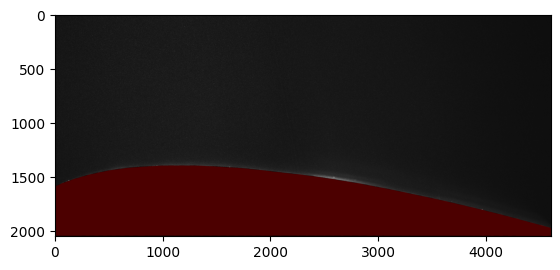

In [7]:

Source = cv2.imread(GenPath)

color_mask = cv2.cvtColor(CroppedMask, cv2.COLOR_GRAY2BGR)

color_mask[CroppedMask == 255] = [255, 0, 0] # Blue BGR

img = cv2.addWeighted(color_mask, 0.3, Source, 1, 0)

plt.imshow(img)

